In [ ]:
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter
import warnings
warnings.filterwarnings("ignore")

DATASET = "icsdataset/hai-security-dataset"
BASE_PATH = "hai-23.05/"

In [ ]:
#loading train files
train_files = [
    "hai-train1.csv",
    "hai-train2.csv",
]

train_dfs = []
for f in train_files:
    df_temp = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        DATASET,
        BASE_PATH + f
    )
    train_dfs.append(df_temp)

train_raw = pd.concat(train_dfs, axis=0)

100%|██████████| 36.6M/36.6M [00:04<00:00, 8.23MB/s]

Extracting zip of hai-train1.csv...


100%|██████████| 38.2M/38.2M [00:04<00:00, 9.54MB/s]

Extracting zip of hai-train2.csv...


In [ ]:
#loading test files
test_files = [
    "hai-test1.csv",
    "hai-test2.csv"
]

test_dfs = []
for f in test_files:
    df_temp = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        DATASET,
        BASE_PATH + f
    )
    test_dfs.append(df_temp)

test_raw = pd.concat(test_dfs, axis=0)

100%|██████████| 7.13M/7.13M [00:02<00:00, 2.67MB/s]

Extracting zip of hai-test1.csv...


100%|██████████| 30.2M/30.2M [00:03<00:00, 8.70MB/s]

Extracting zip of hai-test2.csv...


In [ ]:
#loading label files
label_files = [
    "label-test1.csv",
    "label-test2.csv"
]

label_dfs = []
for f in label_files:
    df_temp = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        DATASET,
        BASE_PATH + f
    )
    label_dfs.append(df_temp)

labels = pd.concat(label_dfs, axis=0)

100%|██████████| 123k/123k [00:00<00:00, 245kB/s]

Extracting zip of label-test1.csv...


100%|██████████| 18.2k/18.2k [00:00<00:00, 12.3MB/s]

Extracting zip of label-test2.csv...


In [ ]:
for df_ in [train_raw, test_raw, labels]:
    if 'timestamp' in df_.columns:
        df_['timestamp'] = pd.to_datetime(
            df_['timestamp'],
            errors='coerce',      # prevents crash
            format='mixed'        # handles mixed formats
        )

        # Drop bad rows if any
        df_.dropna(subset=['timestamp'], inplace=True)

        df_.set_index('timestamp', inplace=True)

# Sort
train_raw = train_raw.sort_index()
test_raw  = test_raw.sort_index()
labels    = labels.sort_index()

## **Preprocessing**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib

#define sensor groups
def get_sensor_groups(columns):
    groups = {
        "P1": [c for c in columns if c.startswith("P1_")],
        "P2": [c for c in columns if c.startswith("P2_")],
        "P3": [c for c in columns if c.startswith("P3_")],
        "P4": [c for c in columns if c.startswith("P4_")],
    }
    #fallback, using all columns if naming will differ
    if not any(groups.values()):
        groups = {"ALL": list(columns)}
    return groups

SENSOR_GROUPS = get_sensor_groups(train_raw.columns)
print("Sensor groups:")
for g, cols in SENSOR_GROUPS.items():
    print(f"  {g}: {len(cols)} sensors")

Sensor groups:
  P1: 37 sensors
  P2: 24 sensors
  P3: 7 sensors
  P4: 11 sensors


In [ ]:
#boolean/binary sensors (do not normalize)
def detect_binary_cols(df, threshold=0.05):
    """Columns with only 0/1 values: do not scale."""
    binary = []
    for col in df.columns:
        unique_ratio = df[col].nunique() / max(len(df), 1)
        if df[col].nunique() <= 3 and df[col].min() >= 0 and df[col].max() <= 1:
            binary.append(col)
    return binary

BINARY_COLS = detect_binary_cols(train_raw)
CONTINUOUS_COLS = [c for c in train_raw.columns if c not in BINARY_COLS]
print(f"\nBinary (not scaled): {len(BINARY_COLS)} cols")
print(f"Continuous (scaled): {len(CONTINUOUS_COLS)} cols")


Binary (not scaled): 16 cols
Continuous (scaled): 70 cols


In [ ]:
#clean + normalize
def preprocess(df, scalers=None, fit=False):
    """
    1. Interpolate gaps (time-aware)
    2. Clip extreme outliers (3-sigma)
    3. MinMax normalize continuous cols (fit on train only)
    Returns: cleaned DataFrame, scalers dict
    """
    df = df.copy()

    #missing values
    df = df.interpolate(method="time").ffill().bfill()

    #clip 3-sigma outliers on continuous cols (fit on train stats)
    if fit:
        clip_stats = {}
        for col in CONTINUOUS_COLS:
            if col in df.columns:
                mu, sigma = df[col].mean(), df[col].std()
                clip_stats[col] = (mu - 3*sigma, mu + 3*sigma)
        preprocess.clip_stats = clip_stats
    if hasattr(preprocess, "clip_stats"):
        for col, (lo, hi) in preprocess.clip_stats.items():
            if col in df.columns:
                df[col] = df[col].clip(lo, hi)

    #normalize continuous columns
    if scalers is None:
        scalers = {}
    continuous_in_df = [c for c in CONTINUOUS_COLS if c in df.columns]
    if fit:
        scaler = MinMaxScaler()
        df[continuous_in_df] = scaler.fit_transform(df[continuous_in_df])
        scalers["main"] = scaler
    else:
        if "main" in scalers:
            # Only transform columns that were in training
            train_cols = scalers["main"].feature_names_in_ if hasattr(scalers["main"], "feature_names_in_") else continuous_in_df
            shared = [c for c in train_cols if c in df.columns]
            df[shared] = scalers["main"].transform(df[shared])
        else:
            scaler = MinMaxScaler()
            df[continuous_in_df] = scaler.fit_transform(df[continuous_in_df])
            scalers["main"] = scaler

    return df, scalers

In [ ]:
train_clean, scalers = preprocess(train_raw, fit=True)
test_clean,  _       = preprocess(test_raw, scalers=scalers, fit=False)

shared_cols = [c for c in train_clean.columns if c in test_clean.columns]
train_clean = train_clean[shared_cols]
test_clean  = test_clean[shared_cols]

print(f"\nAfter preprocessing:")
print(f"  Train: {train_clean.shape}, NaN: {train_clean.isna().sum().sum()}")
print(f"  Test:  {test_clean.shape},  NaN: {test_clean.isna().sum().sum()}")


After preprocessing:
  Train: (572400, 86), NaN: 0
  Test:  (284400, 86),  NaN: 0


In [ ]:
import glob,os
#save scaler
os.makedirs("/content/hai_models", exist_ok=True)
joblib.dump(scalers, "/content/hai_models/scalers.pkl")
print("\nScalers saved.")


Scalers saved.


## **Feature Engineering**

In [ ]:
def engineer_features(df):
    """
    Build features grounded in HAI's PCL attack model.
    SP-PV error, CV deviation, rolling stats, rate-of-change.
    """
    feats = df.copy()
    cols = df.columns.tolist()

    def safe_diff(a, b):
        if a in cols and b in cols:
            return df[a] - df[b]
        return pd.Series(0, index=df.index)

    def safe_abs_diff(a, b):
        return safe_diff(a, b).abs()

    #PCL error features
    # P1-PC pressure loop: B2016 = SP, PIT01 = PV
    feats["feat_P1PC_err"]    = safe_diff("P1_B2016", "P1_PIT01")
    feats["feat_P1PC_cv_dev"] = safe_abs_diff("P1_PCV01D", "P1_PCV01Z")

    # P1-LC level loop: B3004 = SP, LIT01 = PV
    feats["feat_P1LC_err"]    = safe_diff("P1_B3004", "P1_LIT01")
    feats["feat_P1LC_cv_dev"] = safe_abs_diff("P1_LCV01D", "P1_LCV01Z")

    # P1-FC flow loop: B3005 = SP, FT03Z = PV
    feats["feat_P1FC_err"]    = safe_diff("P1_B3005", "P1_FT03Z")
    feats["feat_P1FC_cv_dev"] = safe_abs_diff("P1_FCV03D", "P1_FCV03Z")

    # P1-TC temperature loop: B4022 = SP, TIT01 = PV
    feats["feat_P1TC_err"]    = safe_diff("P1_B4022", "P1_TIT01")

    # P2-SC speed loop: AutoSD = SP, SIT01 = PV
    feats["feat_P2SC_err"]    = safe_diff("P2_AutoSD", "P2_SIT01")
    feats["feat_P2SC_cv_dev"] = safe_abs_diff("P2_SCO",
                                               "P2_SIT01") if "P2_SCO" in cols and "P2_SIT01" in cols else pd.Series(0, index=df.index)

    #Rate-of-change (first derivative — detects sudden jumps)
    for col in [c for c in cols if c.startswith(("P1_B", "P2_AutoSD", "P1_PIT", "P1_LIT", "P1_FT", "P2_SIT"))]:
        feats[f"feat_roc_{col}"] = df[col].diff(1).fillna(0)

    #Rolling statistics (windows in seconds at 1Hz sampling)
    key_sensors = [c for c in cols if any(
        c.startswith(p) for p in ["P1_PIT","P1_LIT","P1_FT","P2_SIT","P1_TIT","P3_LIT"]
    )]
    for col in key_sensors[:12]:  # limit to avoid memory explosion
        for w in [10, 30, 60]:
            r = df[col].rolling(w, min_periods=1)
            feats[f"feat_{col}_mean{w}"] = r.mean()
            feats[f"feat_{col}_std{w}"]  = r.std().fillna(0)
            feats[f"feat_{col}_max{w}"]  = r.max()

    #Valve position anomaly: commanded ≠ actual
    for d_col in [c for c in cols if c.endswith("D") and c[:-1]+"Z" in cols]:
        z_col = d_col[:-1] + "Z"
        feats[f"feat_valve_{d_col}"] = (df[d_col] - df[z_col]).abs()

    feats = feats.fillna(0)
    print(f"Features: {df.shape[1]} raw → {feats.shape[1]} with engineered features")
    return feats

train_feat = engineer_features(train_clean)
test_feat  = engineer_features(test_clean)

train_feat = train_feat.iloc[:200000]
test_feat  = test_feat.iloc[:100000]

FEATURE_COLS = train_feat.columns.tolist()
print(f"Total feature columns: {len(FEATURE_COLS)}")

Features: 86 raw → 221 with engineered features
Features: 86 raw → 221 with engineered features
Total feature columns: 221


## **Sliding window dataset builder**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

SEQ_LEN    = 60   # 60-second lookback window
BATCH_SIZE = 256
N_FEATURES = len(FEATURE_COLS)

class TimeSeriesDataset(Dataset):
    def __init__(self, df, seq_len=SEQ_LEN):
        self.data = torch.FloatTensor(df.values)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        return x  # shape (seq_len, n_features)

train_ds = TimeSeriesDataset(train_feat)
test_ds  = TimeSeriesDataset(test_feat)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")
print(f"Input shape per batch: (batch, {SEQ_LEN}, {N_FEATURES})")

Device: cuda
Train batches: 782, Test batches: 391
Input shape per batch: (batch, 60, 221)


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## **Model 1: LSTM Autoencoder**

In [ ]:
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    """
    Encoder-decoder LSTM. Trained to reconstruct normal sequences.
    High reconstruction error at test time → anomaly.
    """
    def __init__(self, n_features, hidden=128, latent=32, n_layers=2, dropout=0.2):
        super().__init__()
        self.n_features = n_features
        self.hidden     = hidden

        #encoder
        self.encoder_lstm = nn.LSTM(
            n_features, hidden, n_layers,
            batch_first=True, dropout=dropout)
        self.bottleneck = nn.Sequential(
            nn.Linear(hidden, latent),
            nn.ReLU())
        #decoder
        self.expand = nn.Linear(latent, hidden)
        self.decoder_lstm = nn.LSTM(
            hidden, n_features, n_layers,
            batch_first=True, dropout=dropout)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        enc_out, (h_n, _) = self.encoder_lstm(x)
        z = self.bottleneck(h_n[-1])              # (batch, latent)
        h_exp = self.expand(z)                    # (batch, hidden)
        dec_in = h_exp.unsqueeze(1).expand(-1, x.size(1), -1)  # (batch, seq, hidden)
        dec_out, _ = self.decoder_lstm(dec_in)    # (batch, seq, n_features)
        return dec_out, z

    def reconstruction_error(self, x):
        """Per-sample, per-sensor MSE — shape (batch, n_features)"""
        recon, _ = self.forward(x)
        return ((x - recon) ** 2).mean(dim=1)  # mean over time dimension

In [ ]:
def train_lstm_ae(model, loader, epochs=10, lr=1e-3, patience=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5)
    criterion = nn.MSELoss()
    model.to(DEVICE)

    best_loss, patience_ctr, best_state = float("inf"), 0, None

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for batch in loader:
            batch = batch.to(DEVICE)
            recon, _ = model(batch)
            loss = criterion(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        scheduler.step(avg)
        print(f"  Epoch {epoch+1:3d}/{epochs} | Loss: {avg:.6f}")

        if avg < best_loss:
            best_loss = avg
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    print(f"Best loss: {best_loss:.6f}")
    return model

In [ ]:
lstm_ae = LSTMAutoencoder(n_features=N_FEATURES, hidden=128, latent=32)
print(f"LSTM-AE parameters: {sum(p.numel() for p in lstm_ae.parameters()):,}")
lstm_ae = train_lstm_ae(lstm_ae, train_loader, epochs=10)

torch.save(lstm_ae.state_dict(), "/content/hai_models/lstm_ae.pt")
print("LSTM-AE saved.")

LSTM-AE parameters: 1,022,940
  Epoch   1/10 | Loss: 0.021952
  Epoch   2/10 | Loss: 0.010637
  Epoch   3/10 | Loss: 0.008199
  Epoch   4/10 | Loss: 0.007526
  Epoch   5/10 | Loss: 0.006289
  Epoch   6/10 | Loss: 0.004972
  Epoch   7/10 | Loss: 0.004451
  Epoch   8/10 | Loss: 0.004220
  Epoch   9/10 | Loss: 0.003429
  Epoch  10/10 | Loss: 0.003132
Best loss: 0.003132
LSTM-AE saved.


## **Model 2 Transformer Autoencoder**

In [ ]:
class TransformerAE(nn.Module):
    """
    Transformer-based autoencoder.
    Attention weights give built-in sensor importance scores.
    """
    def __init__(self, n_features, d_model=128, nhead=4,
                 num_layers=3, dim_ff=256, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(n_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_ff, dropout=dropout,
            batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, n_features)
        self._attn_weights = None

        # Hook to capture attention weights from last layer
        self.encoder.layers[-1].self_attn.register_forward_hook(self._save_attn)

    def _save_attn(self, module, input, output):
        # output = (attn_output, attn_weights)
        self._attn_weights = output[1] if isinstance(output, tuple) else None

    def forward(self, x):
        h = self.input_proj(x)          # (batch, seq, d_model)
        h = self.encoder(h)             # (batch, seq, d_model)
        recon = self.output_proj(h)     # (batch, seq, n_features)
        return recon

    def reconstruction_error(self, x):
        recon = self.forward(x)
        return ((x - recon) ** 2).mean(dim=1)

    def get_attention(self):
        return self._attn_weights  # (batch, seq, seq)

In [ ]:
def train_transformer_ae(model, loader, epochs=10, lr=5e-4, patience=5):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.MSELoss()
    model.to(DEVICE)

    best_loss, patience_ctr, best_state = float("inf"), 0, None

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for batch in loader:
            batch = batch.to(DEVICE)
            recon = model(batch)
            loss = criterion(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg = total_loss / len(loader)
        print(f"  Epoch {epoch+1:3d}/{epochs} | Loss: {avg:.6f}")

        if avg < best_loss:
            best_loss = avg
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    print(f"Best loss: {best_loss:.6f}")
    return model

In [ ]:
transformer_ae = TransformerAE(n_features=N_FEATURES, d_model=32, nhead=2, num_layers=1)
print(f"Transformer-AE parameters: {sum(p.numel() for p in transformer_ae.parameters()):,}")
transformer_ae = train_transformer_ae(transformer_ae, train_loader, epochs=10)

torch.save(transformer_ae.state_dict(), "/content/hai_models/transformer_ae.pt")
print("Transformer-AE saved.")

Transformer-AE parameters: 35,421
  Epoch   1/10 | Loss: 0.032372
  Epoch   2/10 | Loss: 0.006743
  Epoch   3/10 | Loss: 0.003884
  Epoch   4/10 | Loss: 0.002592
  Epoch   5/10 | Loss: 0.001757
  Epoch   6/10 | Loss: 0.001288
  Epoch   7/10 | Loss: 0.001049
  Epoch   8/10 | Loss: 0.000871
  Epoch   9/10 | Loss: 0.000751
  Epoch  10/10 | Loss: 0.000660
Best loss: 0.000660
Transformer-AE saved.


## **Model 3: Isolation Forest**

In [ ]:
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest...")
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # ~5% anomaly rate in HAI test set
    max_samples="auto",
    random_state=42,
    n_jobs=-1,
    verbose=1)

# Use only raw features for IsoForest (not windowed)
iso_train = train_feat.values
iso_forest.fit(iso_train)

joblib.dump(iso_forest, "/content/hai_models/iso_forest.pkl")
print("Isolation Forest saved.")


Training Isolation Forest...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    1.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.4s


Isolation Forest saved.


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.0s finished


## **Generating Anomaly Scores**

In [ ]:
from tqdm import tqdm

def get_lstm_scores(model, loader, n_sensors):
    """
    Returns:
      recon_error: (N, n_features) per-sensor MSE
      scores:      (N,) mean MSE per timestep
    """
    model.eval()
    all_errors = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="LSTM-AE scoring"):
            batch = batch.to(DEVICE)
            err = model.reconstruction_error(batch)  # (batch, n_features)
            all_errors.append(err.cpu().numpy())
    all_errors = np.vstack(all_errors)  # (N_windows, n_features)
    return all_errors, all_errors.mean(axis=1)

In [ ]:
def get_transformer_scores(model, loader, n_sensors):
    model.eval()
    all_errors = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Transformer scoring"):
            batch = batch.to(DEVICE)
            err = model.reconstruction_error(batch)
            all_errors.append(err.cpu().numpy())
    all_errors = np.vstack(all_errors)
    return all_errors, all_errors.mean(axis=1)

In [ ]:
def get_iso_scores(model, df_feat, seq_len=SEQ_LEN):
    """Score using last timestep of each window."""
    raw_scores = -model.score_samples(df_feat.values)  # higher = more anomalous
    # Align to window output length
    return raw_scores[seq_len:]

print("Scoring test set with all three models...")
lstm_ae.eval()
transformer_ae.eval()

lstm_per_sensor, lstm_scores       = get_lstm_scores(lstm_ae, test_loader, N_FEATURES)
tformer_per_sensor, tformer_scores = get_transformer_scores(transformer_ae, test_loader, N_FEATURES)
iso_scores                          = get_iso_scores(iso_forest, test_feat)

# Align all score arrays to the same length (window offset removes first SEQ_LEN rows)
min_len = min(len(lstm_scores), len(tformer_scores), len(iso_scores))
lstm_scores    = lstm_scores[:min_len]
tformer_scores = tformer_scores[:min_len]
iso_scores     = iso_scores[:min_len]
lstm_per_sensor    = lstm_per_sensor[:min_len]
tformer_per_sensor = tformer_per_sensor[:min_len]

Scoring test set with all three models...


Transformer scoring: 100%|██████████| 391/391 [00:06<00:00, 58.38it/s]
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    1.1s finished


In [ ]:
def normalize_01(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

# ── Ensemble: weighted combination
W_LSTM    = 0.50
W_TFORMER = 0.30
W_ISO     = 0.20

ensemble_score = (
    W_LSTM    * normalize_01(lstm_scores) +
    W_TFORMER * normalize_01(tformer_scores) +
    W_ISO     * normalize_01(iso_scores)
)

print(f"\nScore arrays aligned to length: {min_len}")
print(f"Ensemble score — min: {ensemble_score.min():.4f}, max: {ensemble_score.max():.4f}, "
      f"mean: {ensemble_score.mean():.4f}")


Score arrays aligned to length: 99940
Ensemble score — min: 0.0321, max: 0.9688, mean: 0.2394


## **Adaptive thresholding and anomaly detection**

In [ ]:
def adaptive_threshold(scores, window=300, percentile=95):
    """
    Rolling percentile threshold — adapts to local dynamics.
    Prevents false alarms during legitimate process transitions.
    """
    s = pd.Series(scores)
    thresh = s.rolling(window, min_periods=60).quantile(percentile / 100)
    thresh = thresh.fillna(np.percentile(scores, percentile))
    return thresh.values

# Compute threshold on training scores (fit threshold on normal data)
_, lstm_train_scores   = get_lstm_scores(lstm_ae, train_loader, N_FEATURES)
_, tformer_train_scores = get_transformer_scores(transformer_ae, train_loader, N_FEATURES)
iso_train_scores        = get_iso_scores(iso_forest, train_feat)

min_train = min(len(lstm_train_scores), len(tformer_train_scores), len(iso_train_scores))
train_ensemble = (
    W_LSTM    * normalize_01(lstm_train_scores[:min_train]) +
    W_TFORMER * normalize_01(tformer_train_scores[:min_train]) +
    W_ISO     * normalize_01(iso_train_scores[:min_train])
)

GLOBAL_THRESHOLD = np.percentile(train_ensemble, 95)
test_threshold   = adaptive_threshold(ensemble_score, window=300, percentile=95)
anomaly_flags    = (ensemble_score > test_threshold).astype(int)

print(f"Global threshold (95th pct of train): {GLOBAL_THRESHOLD:.4f}")
print(f"Anomalies detected: {anomaly_flags.sum():,} / {len(anomaly_flags):,} "
      f"({100*anomaly_flags.mean():.2f}%)")

Transformer scoring: 100%|██████████| 782/782 [00:14<00:00, 52.74it/s]
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.4s


Global threshold (95th pct of train): 0.3268
Anomalies detected: 11,922 / 99,940 (11.93%)


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    2.1s finished


## **Root cause and attack type classification**

In [ ]:
# PCL graph — directly from HAI PDF (Figure 3, attack taxonomy)
PCL_GRAPH = {
    "P1-PC": {
        "sp":         "P1_B2016",
        "pv":         "P1_PIT01",
        "cv":         ["P1_PCV01D", "P1_PCV02D"],
        "downstream": ["P4_ST_PT01", "P4_ST_PO"],
        "description": "Boiler pressure control"
    },
    "P1-LC": {
        "sp":         "P1_B3004",
        "pv":         "P1_LIT01",
        "cv":         ["P1_LCV01D"],
        "downstream": ["P1_FT01Z", "P1_FT03Z"],
        "description": "Boiler water level control"
    },
    "P1-FC": {
        "sp":         "P1_B3005",
        "pv":         "P1_FT03",
        "cv":         ["P1_FCV03D"],
        "downstream": ["P1_LIT01"],
        "description": "Boiler flow rate control"
    },
    "P1-TC": {
        "sp":         "P1_B4022",
        "pv":         "P1_TIT01",
        "cv":         ["P1_FCV01D", "P1_FCV02D"],
        "downstream": ["P4_ST_TT01"],
        "description": "Boiler temperature control"
    },
    "P1-CC": {
        "sp":         "P1_PP04SP",
        "pv":         "P1_TIT03",
        "cv":         ["P1_PP04"],
        "downstream": [],
        "description": "Boiler cooling control"
    },
    "P2-SC": {
        "sp":         "P2_AutoSD",
        "pv":         "P2_SIT01",
        "cv":         ["P2_SCO"],
        "downstream": ["P4_ST_PO"],
        "description": "Turbine speed control"
    },
    "P3-LC": {
        "sp":         "P3_LH01",
        "pv":         "P3_LIT01",
        "cv":         ["P3_LCV01D", "P3_LCP01D"],
        "downstream": ["P4_HT_PO"],
        "description": "Water treatment level control"
    },
}

In [ ]:
SENSOR_ROLE_MAP = {}
for loop, cfg in PCL_GRAPH.items():
    SENSOR_ROLE_MAP[cfg["sp"]] = f"SP ({loop})"
    SENSOR_ROLE_MAP[cfg["pv"]] = f"PV ({loop})"
    for cv in cfg["cv"]:
        SENSOR_ROLE_MAP[cv] = f"CV ({loop})"
    for ds in cfg["downstream"]:
        SENSOR_ROLE_MAP[ds] = f"downstream ({loop})"

def get_sensor_role(sensor_name):
    return SENSOR_ROLE_MAP.get(sensor_name, "general sensor")

def find_root_cause(anomalous_sensors, recon_errors_dict):
    """Score each PCL loop based on how many of its sensors are anomalous."""
    scores = {}
    for loop, cfg in PCL_GRAPH.items():
        all_nodes = (
            [cfg["sp"], cfg["pv"]] +
            cfg["cv"] + cfg["downstream"])
        overlap = len(set(anomalous_sensors) & set(all_nodes))
        err_sum = sum(recon_errors_dict.get(s, 0.0) for s in all_nodes)
        scores[loop] = overlap * (1 + err_sum)
    ranked = sorted(scores.items(), key=lambda x: -x[1])
    return ranked  # [(loop_name, score), ...]

def classify_attack(anomalous_sensors, loop_cfg):
    """SP / PV / CV / compound classification per loop."""
    sp = loop_cfg["sp"]
    pv = loop_cfg["pv"]
    cv = loop_cfg["cv"]
    has_sp = sp in anomalous_sensors
    has_pv = pv in anomalous_sensors
    has_cv = any(c in anomalous_sensors for c in cv)

    if has_sp and has_pv and has_cv:
        return "compound_attack"
    if has_sp and has_pv:
        return "SP_manipulation_with_PV_spoofing"
    if has_sp:
        return "SP_manipulation"
    if has_pv and has_cv:
        return "CV_injection_with_PV_spoofing"
    if has_cv:
        return "CV_injection"
    if has_pv:
        return "PV_spoofing"
    return "indirect_effect"

## **Per-sensor contribution + context builder**

In [ ]:
def get_top_sensors(per_sensor_errors, sensor_names, topk=8):
    """Rank sensors by reconstruction error magnitude."""
    available = [s for s in sensor_names if s in FEATURE_COLS]
    # Use index mapping
    idx_map = {name: i for i, name in enumerate(FEATURE_COLS)}
    errors = []
    for name in available:
        if name in idx_map:
            i = idx_map[name]
            if i < per_sensor_errors.shape[0]:
                errors.append((name, float(per_sensor_errors[i])))
    errors.sort(key=lambda x: -x[1])
    return errors[:topk]

In [ ]:
def build_anomaly_context(window_idx, ensemble_score_val,
                           lstm_per_sensor_row, tformer_per_sensor_row,
                           test_timestamps):
    """
    Builds the structured context dict that feeds the LLM prompt.
    This is the 'score file' in structured form.
    """
    # Combine LSTM + Transformer per-sensor errors (equal weight)
    combined_errors = (0.6 * lstm_per_sensor_row +
                       0.4 * tformer_per_sensor_row)

    # Build sensor error dict
    recon_dict = {name: float(combined_errors[i])
                  for i, name in enumerate(FEATURE_COLS)
                  if i < len(combined_errors)}

    # Identify anomalous sensors (above 75th percentile of their own error)
    threshold_val = np.percentile(list(recon_dict.values()), 75)
    anomalous_sensors = [s for s, e in recon_dict.items() if e > threshold_val]

    # Root cause analysis
    root_cause = find_root_cause(anomalous_sensors, recon_dict)
    top_loop   = root_cause[0][0] if root_cause else "unknown"
    top_cfg    = PCL_GRAPH.get(top_loop, {})

    # Attack classification
    attack_type = classify_attack(anomalous_sensors, top_cfg) if top_cfg else "unknown"

    # Top contributing sensors
    top_sensors = get_top_sensors(combined_errors, FEATURE_COLS, topk=8)

    # Timestamp
    ts = test_timestamps[window_idx] if window_idx < len(test_timestamps) else "unknown"

    severity = ("CRITICAL" if ensemble_score_val > 0.85
                else "HIGH"   if ensemble_score_val > 0.70
                else "MEDIUM" if ensemble_score_val > 0.50
                else "LOW")

    return {
        "timestamp":        str(ts),
        "window_idx":       int(window_idx),
        "anomaly_score":    round(float(ensemble_score_val), 4),
        "severity":         severity,
        "top_loop":         top_loop,
        "loop_description": top_cfg.get("description", ""),
        "attack_type":      attack_type,
        "all_root_cause":   [(l, round(s, 4)) for l, s in root_cause[:3]],
        "anomalous_sensors": anomalous_sensors[:10],
        "top_sensors":      [
            {
                "name":  s,
                "error": round(e, 5),
                "role":  get_sensor_role(s)
            }
            for s, e in top_sensors
        ],
        "lstm_score":       round(float(normalize_01(lstm_scores)[window_idx]), 4),
        "transformer_score": round(float(normalize_01(tformer_scores)[window_idx]), 4),
        "iso_score":        round(float(normalize_01(iso_scores)[window_idx]), 4),
    }

# Timestamps aligned to window outputs
test_timestamps = test_clean.index[SEQ_LEN:SEQ_LEN + min_len]

## **Full score file**

In [ ]:
import json
from datetime import datetime

print("Generating score file for all anomaly windows...")

score_records = []
anomaly_indices = np.where(anomaly_flags == 1)[0]
print(f"Processing {len(anomaly_indices)} anomaly windows...")

for i, idx in enumerate(tqdm(anomaly_indices)):
    if idx >= len(test_timestamps):
        continue
    ctx = build_anomaly_context(
        window_idx=idx,
        ensemble_score_val=ensemble_score[idx],
        lstm_per_sensor_row=lstm_per_sensor[idx],
        tformer_per_sensor_row=tformer_per_sensor[idx],
        test_timestamps=test_timestamps
    )
    score_records.append(ctx)

Generating score file for all anomaly windows...
Processing 11922 anomaly windows...


100%|██████████| 11922/11922 [00:19<00:00, 602.39it/s]


In [ ]:
# Save full score file (used by LLM advisory and dashboard)
score_file_path = "/content/hai_models/anomaly_scores.json"
with open(score_file_path, "w") as f:
    json.dump(score_records, f, indent=2, default=str)

# Also save as CSV for easy inspection
score_df = pd.DataFrame([{
    "timestamp":        r["timestamp"],
    "window_idx":       r["window_idx"],
    "anomaly_score":    r["anomaly_score"],
    "severity":         r["severity"],
    "top_loop":         r["top_loop"],
    "attack_type":      r["attack_type"],
    "lstm_score":       r["lstm_score"],
    "transformer_score": r["transformer_score"],
    "iso_score":        r["iso_score"],
    "top_sensor_1":     r["top_sensors"][0]["name"] if r["top_sensors"] else "",
    "top_sensor_2":     r["top_sensors"][1]["name"] if len(r["top_sensors"]) > 1 else "",
    "top_sensor_3":     r["top_sensors"][2]["name"] if len(r["top_sensors"]) > 2 else "",
} for r in score_records])

csv_path = "/content/hai_models/anomaly_scores.csv"
score_df.to_csv(csv_path, index=False)

In [ ]:
# Save full ensemble scores for every timestep (not just anomalies)
full_scores_df = pd.DataFrame({
    "timestamp":       test_timestamps,
    "ensemble_score":  ensemble_score[:len(test_timestamps)],
    "threshold":       test_threshold[:len(test_timestamps)],
    "anomaly_flag":    anomaly_flags[:len(test_timestamps)],
    "lstm_score":      normalize_01(lstm_scores)[:len(test_timestamps)],
    "transformer_score": normalize_01(tformer_scores)[:len(test_timestamps)],
    "iso_score":       normalize_01(iso_scores)[:len(test_timestamps)],
})
full_scores_df.to_csv("/content/hai_models/full_scores.csv", index=False)

print(f"\nScore file:         {score_file_path}  ({len(score_records)} anomaly events)")
print(f"Anomaly CSV:        {csv_path}")
print(f"Full timeline CSV:  /content/hai_models/full_scores.csv")
print(f"\nSample record:\n{json.dumps(score_records[0] if score_records else {}, indent=2)}")


Score file:         /content/hai_models/anomaly_scores.json  (11922 anomaly events)
Anomaly CSV:        /content/hai_models/anomaly_scores.csv
Full timeline CSV:  /content/hai_models/full_scores.csv

Sample record:
{
  "timestamp": "2022-08-12 16:02:31",
  "window_idx": 90,
  "anomaly_score": 0.1427,
  "severity": "LOW",
  "top_loop": "P3-LC",
  "loop_description": "Water treatment level control",
  "attack_type": "CV_injection_with_PV_spoofing",
  "all_root_cause": [
    [
      "P3-LC",
      3.213
    ],
    [
      "P1-CC",
      2.6821
    ],
    [
      "P1-LC",
      2.0875
    ]
  ],
  "anomalous_sensors": [
    "P1_FT03",
    "P1_FT03Z",
    "P1_LIT01",
    "P1_PCV01D",
    "P1_PCV01Z",
    "P1_PCV02Z",
    "P1_PP04SP",
    "P1_TIT01",
    "P1_TIT03",
    "P2_24Vdc"
  ],
  "top_sensors": [
    {
      "name": "P1_PCV02Z",
      "error": 0.38683,
      "role": "general sensor"
    },
    {
      "name": "P1_PP04SP",
      "error": 0.32427,
      "role": "SP (P1-CC)"
    },
   

## **Evaluation**

In [ ]:
def evaluate_model(labels_df, anomaly_flags, test_timestamps):
    """
    Evaluate anomaly detection using standard classification metrics.
    Aligns predictions with ground truth labels.
    """
    try:
        import pandas as pd
        from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

        # Build prediction series
        y_pred = pd.Series(anomaly_flags[:len(test_timestamps)],
                           index=test_timestamps).clip(0, 1).astype(int)

        # Find label column
        label_col = None
        for col in labels_df.columns:
            if "attack" in col.lower() or col == labels_df.columns[0]:
                label_col = col
                break

        if label_col is None:
            print("No attack column found in labels.")
            return

        # Align labels
        y_true = labels_df[label_col].reindex(test_timestamps, method="nearest")
        y_true = y_true.fillna(0).clip(0, 1).astype(int)

        # Convert to numpy
        y_true_vals = y_true.values
        y_pred_vals = y_pred.values

        # Metrics
        precision = precision_score(y_true_vals, y_pred_vals)
        recall    = recall_score(y_true_vals, y_pred_vals)
        f1        = f1_score(y_true_vals, y_pred_vals)

        print("\n── Evaluation (Standard Metrics) ───────────")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1 Score:  {f1:.4f}")

        print("\n── Classification Report ─────────────────")
        print(classification_report(y_true_vals, y_pred_vals,
                                    target_names=["Normal", "Attack"]))

        return precision, recall, f1

    except Exception as e:
        print(f"Evaluation error: {e}")

## **LLM Advisory System**

In [ ]:
# ── CELL 16: LLM Advisory System (Groq — FREE) ───────────────

!pip install groq -q

import groq, os, time, json
from tqdm import tqdm
from google.colab import userdata


# Securely load API key from Colab Secrets
try:
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
except Exception:
    raise ValueError(
        "Key not found. Go to left sidebar → Secrets → "
        "Add secret name: GROQ_API_KEY and paste your key"
    )


SYSTEM_PROMPT = """You are an expert ICS security analyst for the HAI testbed — a system combining
steam-turbine power generation (boiler + turbine) and pumped-storage hydropower (water treatment).

The system has seven process control loops (PCLs):
- P1-PC: Boiler pressure control     | SP: B2016 → CV: PCV01D/02D → PV: PIT01
- P1-LC: Boiler level control        | SP: B3004 → CV: LCV01D     → PV: LIT01
- P1-FC: Boiler flow control         | SP: B3005 → CV: FCV03D     → PV: FT03
- P1-TC: Boiler temperature control  | SP: B4022 → CV: FCV01D/02D → PV: TIT01
- P1-CC: Boiler cooling control      | SP: PP04SP → CV: PP04      → PV: TIT03
- P2-SC: Turbine speed control       | SP: AutoSD → CV: SCO       → PV: SIT01
- P3-LC: Water treatment level       | SP: LH01/LL01 → CV: LCV01D/LCP01D → PV: LIT01

Attack taxonomy (from HAI paper):
- SP_manipulation: Attacker modified setpoint via OWS/HMI — process drifts silently
- CV_injection: Attacker forced control valve output — physical damage risk
- PV_spoofing: False sensor readings injected — masks true process state
- SP_manipulation_with_PV_spoofing: Compound attack — setpoint changed + sensor hidden
- CV_injection_with_PV_spoofing: Most dangerous — valve forced + effect hidden
- compound_attack: Multiple attack vectors simultaneously
- indirect_effect: Downstream sensor affected by upstream attack

Your response format must be:
1. SUMMARY (2 sentences — what is happening and why it matters)
2. EVIDENCE (list the specific sensors, their roles, and what the data shows)
3. PROBABLE ATTACK SCENARIO (cite the HAI attack type AP__ or AE__ if recognisable)
4. IMMEDIATE ACTIONS (numbered, operator-actionable, tag-specific)
5. SENSORS TO VERIFY ON OWS (list exact tag names)
6. RISK LEVEL: LOW / MEDIUM / HIGH / CRITICAL

Use technical ICS/SCADA terminology. Be concise and actionable. Reference exact sensor tags."""


def build_llm_prompt(context: dict) -> str:
    sensors_str = "\n".join(
        f"  • {s['name']:20s} | role: {s['role']:30s} | recon error: {s['error']:.5f}"
        for s in context["top_sensors"]
    )

    root_cause_str = " → ".join(
        f"{loop} ({score:.3f})"
        for loop, score in context["all_root_cause"]
    )

    shap_str = ""
    window_idx = context.get("window_idx")

    if window_idx is not None and "shap_top_by_idx" in globals():
        if window_idx in shap_top_by_idx:
            shap_lines = "\n".join(
                f"  • {f['feature']:30s} SHAP={f['shap_value']:+.5f}  ({f['direction']})"
                for f in shap_top_by_idx[window_idx]
            )
            shap_str = f"\nSHAP explanation (top features driving anomaly decision):\n{shap_lines}\n"

    return f"""ANOMALY DETECTED
================
Timestamp:       {context['timestamp']}
Anomaly score:   {context['anomaly_score']:.4f}  (severity: {context['severity']})
Primary loop:    {context['top_loop']} — {context['loop_description']}
Attack type:     {context['attack_type']}
Root cause path: {root_cause_str}

Model scores:
  LSTM-AE score:          {context['lstm_score']:.4f}
  Transformer-AE score:   {context['transformer_score']:.4f}
  Isolation Forest score: {context['iso_score']:.4f}

Top anomalous sensors (ranked by reconstruction error):
{sensors_str}
{shap_str}
Anomalous sensor set: {', '.join(context['anomalous_sensors'][:8])}

Please provide operator advisory guidance."""


class LLMAdvisor:
    def __init__(self, api_key=None):
        key = api_key or os.environ.get("GROQ_API_KEY", "")
        if not key:
            raise ValueError("Set GROQ_API_KEY using Colab Secrets")
        self.client = groq.Groq(api_key=key)
        self.model = "llama-3.1-8b-instant"
        self.cache = {}

    def advise(self, context: dict, use_cache=True) -> str:
        cache_key = f"{context['top_loop']}_{context['attack_type']}_{context['severity']}"

        if use_cache and cache_key in self.cache:
            return self.cache[cache_key]

        prompt = build_llm_prompt(context)

        try:
            response = self.client.chat.completions.create(
                model=self.model,
                max_tokens=800,
                temperature=0.2,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": prompt}
                ]
            )

            text = response.choices[0].message.content

            if use_cache:
                self.cache[cache_key] = text

            return text

        except Exception as e:
            return f"LLM advisory unavailable: {e}"

    def batch_advise(self, score_records, max_alerts=20, severity_filter="MEDIUM"):
        sev_order = {"LOW": 0, "MEDIUM": 1, "HIGH": 2, "CRITICAL": 3}
        min_sev = sev_order.get(severity_filter, 1)

        filtered = [
            r for r in score_records
            if sev_order.get(r["severity"], 0) >= min_sev
        ]

        filtered = sorted(filtered, key=lambda x: -x["anomaly_score"])[:max_alerts]

        print(f"Generating advisories for {len(filtered)} events (severity >= {severity_filter})...")

        results = []

        for ctx in tqdm(filtered):
            advisory = self.advise(ctx)
            results.append({"context": ctx, "advisory": advisory})
            time.sleep(0.5)

        return results


# Activate and test
advisor = LLMAdvisor()

if score_records:
    print("Testing with first anomaly event...\n")
    test_advisory = advisor.advise(score_records[0])
    print(test_advisory)


# Batch process HIGH + CRITICAL events
advisories = advisor.batch_advise(
    score_records,
    max_alerts=20,
    severity_filter="HIGH"
)

print(f"\nDone. {len(advisories)} advisories generated.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 11.1 MB/s eta 0:00:00
Testing with first anomaly event...

**SUMMARY**
Anomaly detected in the P3-LC water treatment level control loop, indicating a potential CV_injection_with_PV_spoofing attack. The attack may have been triggered by a manipulated setpoint (P1_PP04SP) and a false sensor reading (P1_PCV02Z), affecting the boiler cooling control (P1-CC) and boiler level control (P1-LC) loops.

**EVIDENCE**

| Sensor Tag | Role | Data |
| --- | --- | --- |
| P1_PP04SP | Setpoint (P1-CC) | Manipulated setpoint value (deviation from normal) |
| P1_PCV02Z | General sensor | False sensor reading (high reconstruction error) |
| P1_FT03 | General sensor | Affected by upstream attack (indirect effect) |
| P1_FT03Z | General sensor | Affected by upstream attack (indirect effect) |
| P1_LIT01 | Process variable (P1-LC) | Affected by upstream attack (indirect effect) |
| P1_PCV01D | Control valve output (P1-LC) | Affected by upstream atta

100%|██████████| 20/20 [00:12<00:00,  1.63it/s]


Done. 20 advisories generated.


Computing SHAP values for Isolation Forest...
(This takes 1-2 minutes for 200 anomaly windows)
SHAP values shape: (200, 221)
Features explained: 221


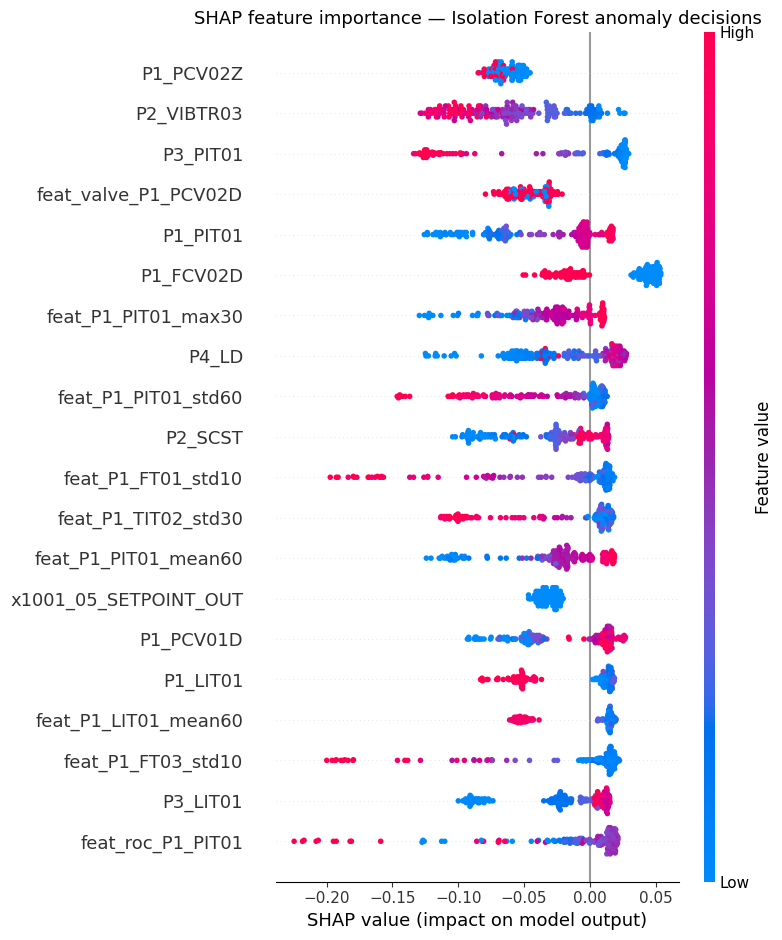

SHAP summary plot saved: /content/hai_models/shap_summary.png


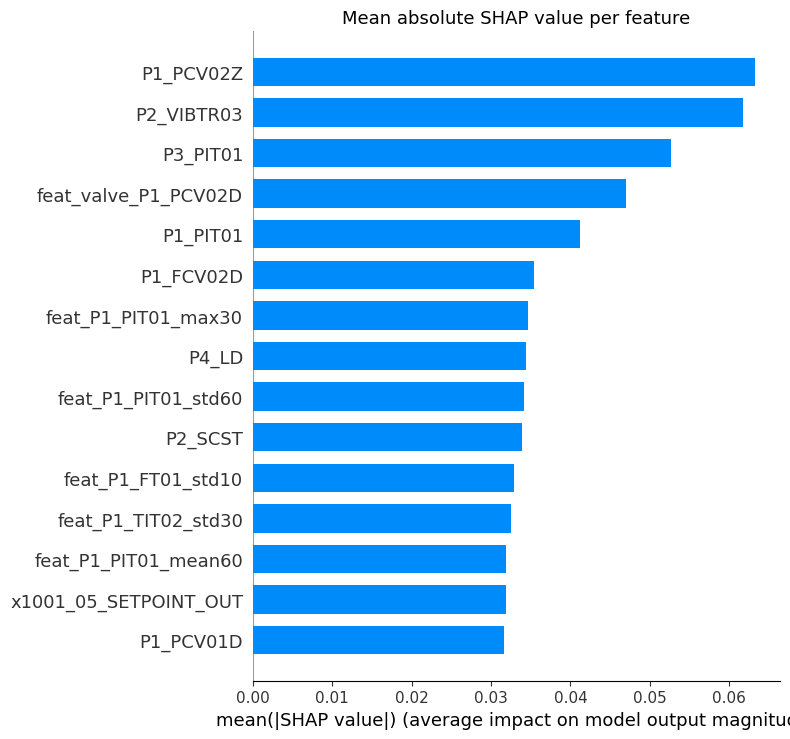

SHAP bar plot saved: /content/hai_models/shap_bar.png

SHAP top features stored for 200 anomaly windows.
SHAP features saved: /content/hai_models/shap_top_features.json

Example SHAP output for window 90:
  ▼ P1_LIT01                             SHAP = -0.07828
  ▼ P1_PCV02Z                            SHAP = -0.07452
  ▼ feat_P1_LIT01_max10                  SHAP = -0.06414
  ▼ feat_P1_LIT01_mean10                 SHAP = -0.05898
  ▼ P2_VIBTR03                           SHAP = -0.05823
  ▼ x1002_07_SETPOINT_OUT                SHAP = -0.05176

Re-running batch advisory with SHAP context included in prompts...
Generating advisories for 20 events (severity >= HIGH)...


100%|██████████| 20/20 [00:10<00:00,  1.99it/s]

Done. 20 advisories generated with SHAP context.


In [ ]:
import shap
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print("Computing SHAP values for Isolation Forest...")
print("(This takes 1-2 minutes for 200 anomaly windows)")

# Background sample — 500 rows from training data is enough
background_sample = train_feat.sample(n=500, random_state=42)

# TreeExplainer works natively on IsolationForest — fast, exact, no approximation
explainer = shap.TreeExplainer(iso_forest)

# Compute SHAP only for anomalous windows (saves time + memory)
# Cap at 200 to avoid Colab RAM issues
n_shap = min(200, len(anomaly_indices))
anomaly_feat_rows = test_feat.iloc[anomaly_indices[:n_shap]]
shap_values = explainer.shap_values(anomaly_feat_rows)

# shap_values shape: (n_anomalies, n_features)
# Positive value = pushed this window toward anomaly decision
# Negative value = pulled this window toward normal decision

print(f"SHAP values shape: {shap_values.shape}")
print(f"Features explained: {shap_values.shape[1]}")

# ── Global summary plot — top 20 most important features across all anomalies
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    anomaly_feat_rows,
    feature_names=FEATURE_COLS,
    max_display=20,
    show=False,
    plot_type="dot"
)
plt.title("SHAP feature importance — Isolation Forest anomaly decisions", fontsize=13)
plt.tight_layout()
plt.savefig("/content/hai_models/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP summary plot saved: /content/hai_models/shap_summary.png")

# ── Bar plot — mean absolute SHAP per feature
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    anomaly_feat_rows,
    feature_names=FEATURE_COLS,
    max_display=15,
    show=False,
    plot_type="bar"
)
plt.title("Mean absolute SHAP value per feature", fontsize=13)
plt.tight_layout()
plt.savefig("/content/hai_models/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP bar plot saved: /content/hai_models/shap_bar.png")


# ── Per-anomaly SHAP top-features builder
def get_shap_top_features(shap_row, feature_names, topk=6):
    """Return top-k features with highest absolute SHAP contribution."""
    abs_shap = np.abs(shap_row)
    top_idx  = np.argsort(abs_shap)[::-1][:topk]
    return [
        {
            "feature":    feature_names[i],
            "shap_value": round(float(shap_row[i]), 5),
            "direction":  "toward anomaly" if shap_row[i] > 0 else "toward normal",
            "magnitude":  round(float(abs_shap[i]), 5),
        }
        for i in top_idx
    ]


# Store SHAP top features indexed by window index
# This dict is automatically read by build_llm_prompt() in Cell 16
shap_top_by_idx = {}
for k, idx in enumerate(anomaly_indices[:n_shap]):
    shap_top_by_idx[int(idx)] = get_shap_top_features(shap_values[k], FEATURE_COLS)

print(f"\nSHAP top features stored for {len(shap_top_by_idx)} anomaly windows.")

# ── Save SHAP results to disk
shap_export = {
    str(idx): features
    for idx, features in shap_top_by_idx.items()
}
with open("/content/hai_models/shap_top_features.json", "w") as f:
    json.dump(shap_export, f, indent=2)
print("SHAP features saved: /content/hai_models/shap_top_features.json")

# ── Show example for first anomaly
first_idx = int(anomaly_indices[0])
print(f"\nExample SHAP output for window {first_idx}:")
for feat in shap_top_by_idx[first_idx]:
    direction_arrow = "▲" if feat["direction"] == "toward anomaly" else "▼"
    print(f"  {direction_arrow} {feat['feature']:35s}  SHAP = {feat['shap_value']:+.5f}")

# ── Re-run batch advisory now that SHAP is available
# SHAP values are automatically picked up by build_llm_prompt()
print("\nRe-running batch advisory with SHAP context included in prompts...")
advisories = advisor.batch_advise(
    score_records,
    max_alerts=20,
    severity_filter="HIGH"
)
print(f"Done. {len(advisories)} advisories generated with SHAP context.")

## **Saving Advisories files**

In [ ]:
def save_advisories(advisories, path="/content/hai_models/advisories.json"):
    """Save LLM advisory results alongside their context."""
    output = []
    for item in advisories:
        output.append({
            "timestamp":     item["context"]["timestamp"],
            "severity":      item["context"]["severity"],
            "anomaly_score": item["context"]["anomaly_score"],
            "top_loop":      item["context"]["top_loop"],
            "attack_type":   item["context"]["attack_type"],
            "advisory":      item["advisory"],
        })
    with open(path, "w") as f:
        json.dump(output, f, indent=2)
    # Also save as CSV
    csv_path = path.replace(".json", ".csv")
    pd.DataFrame(output).to_csv(csv_path, index=False)
    print(f"Advisories saved: {path}")
    print(f"Advisories CSV:   {csv_path}")

## **Visualization**

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

def plot_anomaly_timeline(test_df, full_scores_df, sensor_list=None, title="Anomaly Timeline"):
    """
    Optimized version:
    - Limits data size
    - Limits anomaly shading
    - Faster rendering
    """

    MAX_POINTS = 20000
    if len(full_scores_df) > MAX_POINTS:
        full_scores_df = full_scores_df.iloc[:MAX_POINTS]
        test_df = test_df.iloc[:MAX_POINTS]

    if sensor_list is None:
        sensor_list = ["P1_PIT01", "P1_LIT01", "P1_FT03Z", "P2_SIT01"]
        sensor_list = [s for s in sensor_list if s in test_df.columns][:4]

    n_panels = 1 + len(sensor_list)

    fig = make_subplots(
        rows=n_panels, cols=1,
        shared_xaxes=True,
        subplot_titles=["Ensemble anomaly score"] + [f"Sensor: {s}" for s in sensor_list],
        vertical_spacing=0.04
    )

    ts = full_scores_df["timestamp"]

    # Panel 1: anomaly score
    fig.add_trace(go.Scatter(
        x=ts, y=full_scores_df["ensemble_score"],
        name="Ensemble score", line=dict(width=1)),
        row=1, col=1)

    fig.add_trace(go.Scatter(
        x=ts, y=full_scores_df["threshold"],
        name="Threshold", line=dict(dash="dash", width=1)),
        row=1, col=1)


    anom_mask = full_scores_df["anomaly_flag"] == 1
    anom_starts = ts[anom_mask & ~anom_mask.shift(1, fill_value=False)]
    anom_ends   = ts[anom_mask & ~anom_mask.shift(-1, fill_value=False)]

    MAX_REGIONS = 20  # limit shading
    for s, e in list(zip(anom_starts, anom_ends))[:MAX_REGIONS]:
        for row in range(1, n_panels + 1):
            fig.add_vrect(
                x0=s, x1=e,
                fillcolor="red", opacity=0.1,
                layer="below", line_width=0,
                row=row, col=1
            )

    # Sensor panels
    sensor_ts = test_df.index
    for i, sensor in enumerate(sensor_list, start=2):
        fig.add_trace(go.Scatter(
            x=sensor_ts, y=test_df[sensor],
            name=sensor, line=dict(width=0.8)),
            row=i, col=1)

    fig.update_layout(
        height=250 * n_panels,
        title=title,
        showlegend=True,
        template="plotly_white",
        font=dict(size=11)
    )

    fig.show()

    fig.write_html("/content/hai_models/anomaly_timeline.html")
    print("Saved: /content/hai_models/anomaly_timeline.html")



def plot_sensor_correlation_heatmap(df, title="Sensor correlation heatmap"):
    """Optimized correlation heatmap"""

    # 🔥 LIMIT DATA SIZE
    df = df.iloc[:20000]

    key_sensors = [c for c in df.columns
                   if any(c.startswith(p) for p in
                          ["P1_PIT","P1_LIT","P1_FT","P2_SIT","P1_TIT","P3_LIT",
                           "P1_B2016","P1_B3004","P1_B3005","P1_PCV","P1_LCV"])][:15]

    corr = df[key_sensors].corr()

    fig = px.imshow(
        corr,
        title=title,
        color_continuous_scale="RdBu_r",
        zmin=-1, zmax=1,
        aspect="auto"
    )

    fig.update_layout(height=500, template="plotly_white")
    fig.show()

    fig.write_html("/content/hai_models/correlation_heatmap.html")
    print("Saved: /content/hai_models/correlation_heatmap.html")



def plot_score_distribution(ensemble_score, anomaly_flags, threshold_val):
    """Histogram of anomaly scores"""

    fig = go.Figure()

    fig.add_trace(go.Histogram(
        x=ensemble_score[anomaly_flags == 0],
        name="Normal", opacity=0.7, nbinsx=60))

    fig.add_trace(go.Histogram(
        x=ensemble_score[anomaly_flags == 1],
        name="Anomaly", opacity=0.7, nbinsx=60))

    fig.add_vline(
        x=threshold_val,
        line_dash="dash",
        annotation_text="Threshold"
    )

    fig.update_layout(
        barmode="overlay",
        title="Ensemble score distribution",
        xaxis_title="Score",
        yaxis_title="Count",
        template="plotly_white"
    )

    fig.show()



plot_score_distribution(ensemble_score, anomaly_flags, GLOBAL_THRESHOLD)

plot_sensor_correlation_heatmap(test_clean)

if len(full_scores_df) > 0:
    plot_anomaly_timeline(test_clean, full_scores_df)

Saved: /content/hai_models/correlation_heatmap.html


Saved: /content/hai_models/anomaly_timeline.html


## **Saving all models**

In [ ]:
import json

# Save model metadata
metadata = {
    "created_at":       datetime.now().isoformat(),
    "n_features":       N_FEATURES,
    "feature_cols":     FEATURE_COLS,
    "seq_len":          SEQ_LEN,
    "ensemble_weights": {
        "lstm_ae":       W_LSTM,
        "transformer_ae": W_TFORMER,
        "iso_forest":    W_ISO,
    },
    "threshold":        float(GLOBAL_THRESHOLD),
    "sensor_groups":    {k: v for k, v in SENSOR_GROUPS.items()},
    "binary_cols":      BINARY_COLS,
    "pcl_graph":        PCL_GRAPH,
    "train_shape":      list(train_clean.shape),
    "test_shape":       list(test_clean.shape),
    "total_anomalies":  int(anomaly_flags.sum()),
    "anomaly_rate":     float(anomaly_flags.mean()),
}

with open("/content/hai_models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Final save of all torch models
torch.save({
    "model_state":  lstm_ae.state_dict(),
    "n_features":   N_FEATURES,
    "hidden":       128,
    "latent":       32,
    "n_layers":     2,
}, "/content/hai_models/lstm_ae_full.pt")

torch.save({
    "model_state":  transformer_ae.state_dict(),
    "n_features":   N_FEATURES,
    "d_model":      64,
    "nhead":        4,
    "num_layers":   2,
}, "/content/hai_models/transformer_ae_full.pt")

joblib.dump(iso_forest, "/content/hai_models/iso_forest.pkl")
joblib.dump(scalers,    "/content/hai_models/scalers.pkl")

# Save feature column list (critical for VS Code inference)
with open("/content/hai_models/feature_cols.json", "w") as f:
    json.dump(FEATURE_COLS, f)

print("\n── All files saved ─────────────────────────────")
for f in sorted(os.listdir("/content/hai_models")):
    path = f"/content/hai_models/{f}"
    size = os.path.getsize(path)
    print(f"  {f:40s}  {size/1024:.1f} KB")


── All files saved ─────────────────────────────
  anomaly_scores.csv                        1480.4 KB
  anomaly_scores.json                       18730.7 KB
  anomaly_timeline.html                     9309.1 KB
  correlation_heatmap.html                  4464.3 KB
  feature_cols.json                         4.1 KB
  full_scores.csv                           9991.6 KB
  iso_forest.pkl                            4620.9 KB
  lstm_ae.pt                                3999.9 KB
  lstm_ae_full.pt                           4000.4 KB
  metadata.json                             8.7 KB
  scalers.pkl                               4.5 KB
  shap_bar.png                              90.1 KB
  shap_summary.png                          243.3 KB
  shap_top_features.json                    168.6 KB
  transformer_ae.pt                         144.8 KB
  transformer_ae_full.pt                    145.1 KB


In [ ]:
# ZIP the folder
!zip -r /content/hai_models.zip /content/hai_models/

# Download it
from google.colab import files
files.download('/content/hai_models.zip')

updating: content/hai_models/ (stored 0%)
updating: content/hai_models/transformer_ae_full.pt (deflated 9%)
updating: content/hai_models/iso_forest.pkl (deflated 76%)
updating: content/hai_models/shap_summary.png (deflated 5%)
updating: content/hai_models/lstm_ae.pt (deflated 6%)
updating: content/hai_models/feature_cols.json (deflated 82%)
updating: content/hai_models/full_scores.csv (deflated 67%)
updating: content/hai_models/transformer_ae.pt (deflated 9%)
updating: content/hai_models/anomaly_timeline.html (deflated 79%)
updating: content/hai_models/anomaly_scores.csv (deflated 86%)
updating: content/hai_models/scalers.pkl (deflated 32%)
updating: content/hai_models/metadata.json (deflated 82%)
updating: content/hai_models/lstm_ae_full.pt (deflated 6%)
updating: content/hai_models/correlation_heatmap.html (deflated 71%)
updating: content/hai_models/shap_top_features.json (deflated 94%)
updating: content/hai_models/shap_bar.png (deflated 20%)
updating: content/hai_models/anomaly_scor

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>